In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sig

Importo el archivo .csv, usando la columna 'date' como separador.

In [3]:
df = pd.read_csv('./ruido_urbano.csv', parse_dates=['date'],index_col='date')

Analizo el DataFrame

In [4]:
df.head()

,id,value,f500,seg,f125,lMin,f1000,f8000,f4000,soundExpLVL,...,memo,timeStamp,f31,f2000,lMax,min,global,cpu,temp,f250
date,,,,,,,,,,,,,,,,,,,,,
2021-08-31 15:35:01+00:00,C06lct7WIdrs1VXhiI5s,71.94,63.88,46,55.83,57.74,66.86,52.97,63.40,74.02,...,19.09,1630424101,44.50,65.95,77.01,34.0,71.94,7.4,60.15,61.78
2021-08-31 15:33:00+00:00,T6MkNQko71mAFliVjpRp,77.24,73.99,46,57.43,62.05,69.70,54.39,66.30,79.32,...,19.08,1630423980,43.29,68.65,90.24,32.0,77.24,7.4,60.15,67.84
2021-08-31 15:31:00+00:00,SW0E8AX8QTJOGadJIIE2,77.38,74.15,46,58.28,59.43,69.88,53.68,66.05,79.46,...,19.10,1630423860,42.26,68.62,90.24,30.0,77.38,7.7,60.15,68.20
2021-08-31 15:29:01+00:00,BvWFZZ0gbC2eHwMb8t1r,72.83,66.10,47,57.46,57.02,65.80,54.87,64.85,74.91,...,19.10,1630423741,45.22,66.97,77.09,28.0,72.83,7.0,60.15,63.62
2021-08-31 15:27:01+00:00,gUS1NnfMPyzTV4qqk8Ey,72.48,64.89,46,56.34,59.05,65.53,55.14,65.39,74.56,...,19.07,1630423621,45.29,67.06,76.83,26.0,72.48,7.8,60.15,62.08


En esta oportunidad, los datos que me interesan son los de la columna 'value'. Los grafico usando la fecha como eje X.

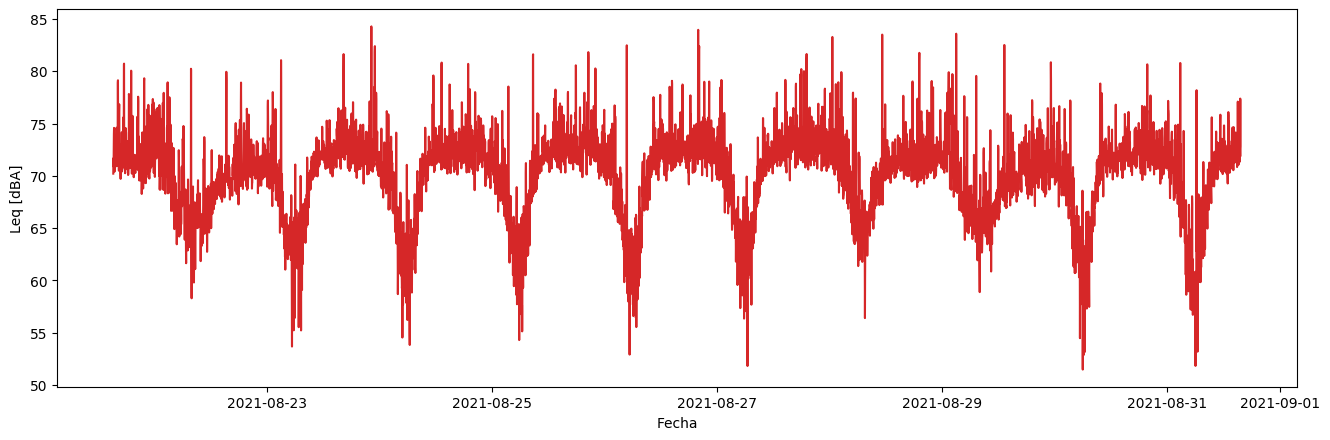

In [5]:
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index, df.value, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [dBA]')
plt.show()

Se ve claramente que existe una periodicidad en los datos. Hago un análisis en frecuencia para conocer mejor la señal. Arranco pasando de dBA a pascales.

In [6]:
pref = 2e-5
df.value = 10**(df.value/20)*pref

Grafico para verque esté todo en orden:

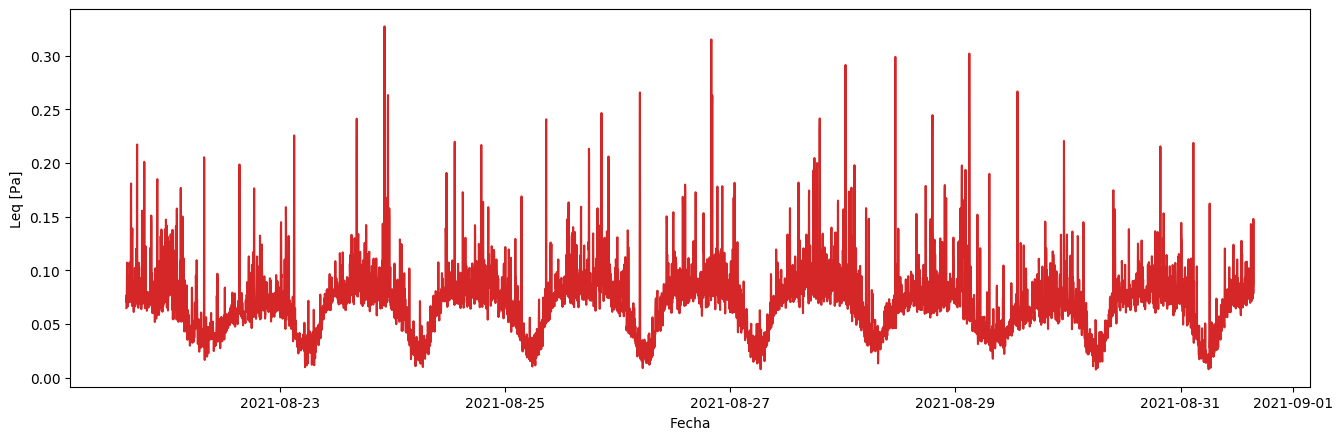

In [7]:
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index, df.value, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [Pa]')
plt.show()

Ahora sí, análisis en frecuencia.

In [8]:
val = df.value
val_f = np.fft.rfft(val) #es una señal real, calculo la mitad del espectro

Grafico el espectro

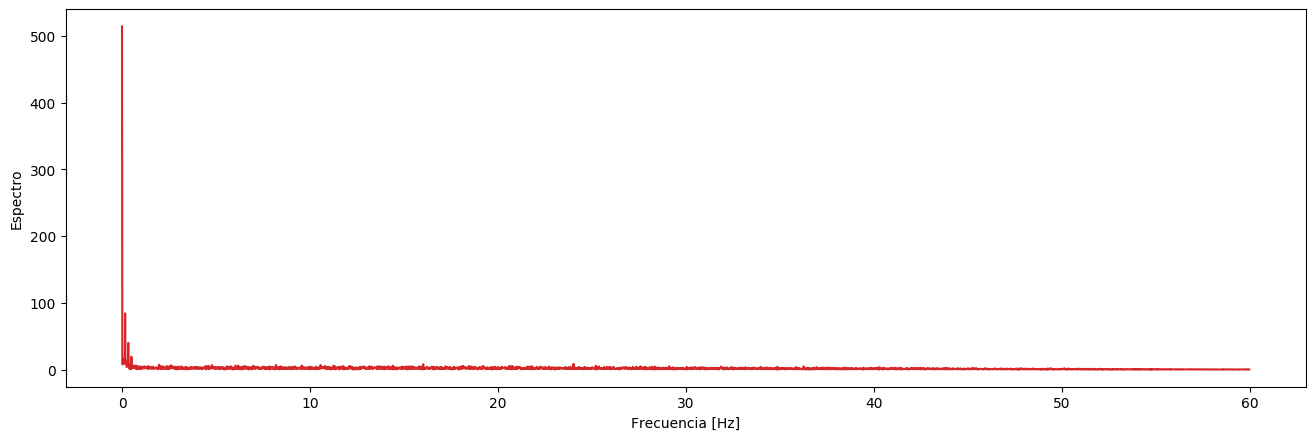

In [9]:
fs = 1/120
max_f = (1//fs)/2
f = np.arange(0,max_f,max_f/len(val_f))
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:-1], abs(val_f), color='tab:red')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Espectro')
plt.show()

No se ve nada, pruebo escala logarítmica en el eje y.

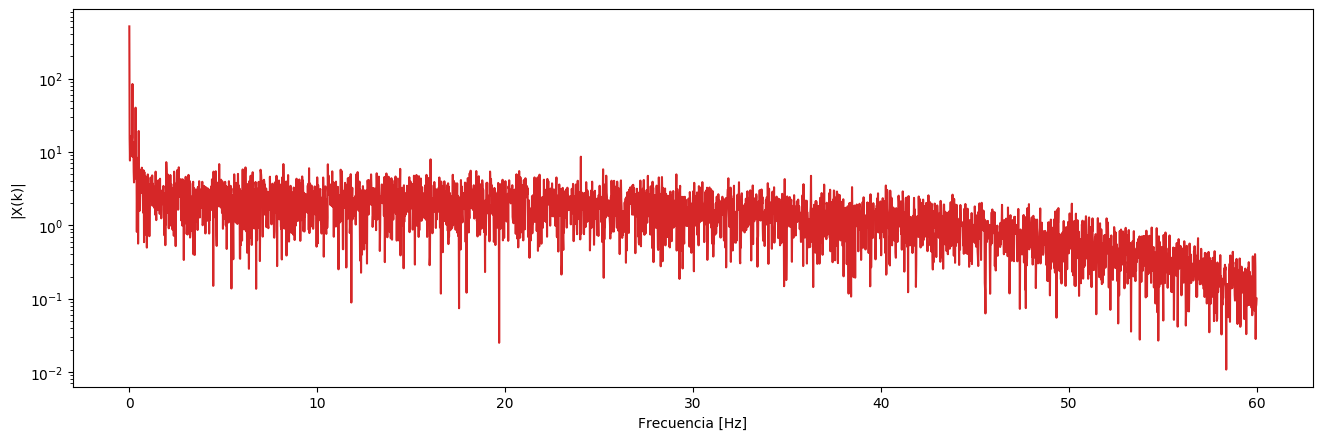

In [10]:
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:-1], abs(val_f), color='tab:red')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(k)|')
plt.yscale('log')
plt.show()

Algo mejor, pruebo graficando una porción del espectro nada más, la de baja frecuencia que es donde parece haber más información.

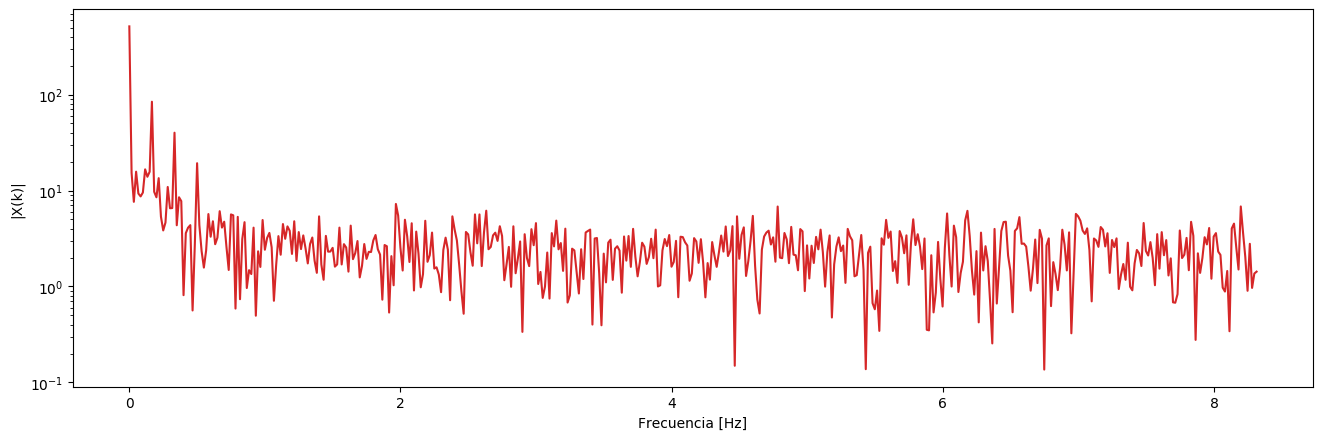

In [11]:
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:500], abs(val_f[:500]), color='tab:red')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(k)|')
plt.yscale('log')
plt.show()

Evidentemente la fundamental es de muy baja frecuencia, menos de 5 Hz. Es lógico si recordamos que los mínimos del primer gráfico (muy probablemente) corresponden a la noche de cada uno de los 10 días bajo análisis. 

Pasemos al filtro ahora, su respuesta en frecuencia es:
$$
|H(e^{j\omega})| = \left|\frac{1}{M}\frac{sen(\omega  M/2)}{sen(\omega /2)}\right|$$

en donde $M$ es el largo de la ventana rectangular (respuesta al impulso del filtro de media movil).

Por ejemplo, usando una ventana de 25 muestras tenemos la siguiente respuesta:

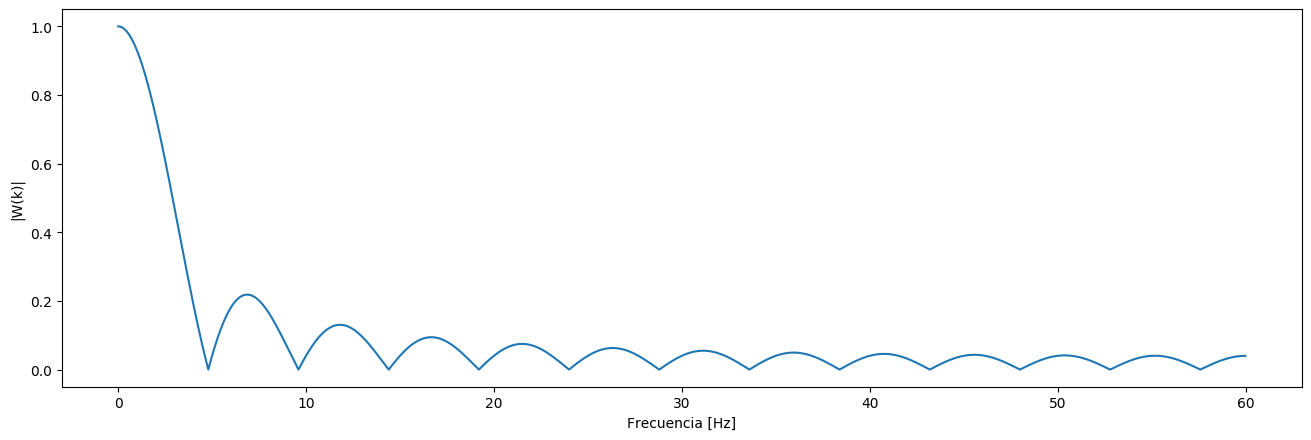

In [12]:
w = np.append(np.ones(25),np.zeros(len(val) - 25))
w = w / (len(w))
w_f = np.fft.rfft(w)/np.max(np.fft.rfft(w))
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:-1],abs(w_f))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|W(k)|')
plt.show()

El filtro de media movil no es más que un filtro pasa bajos. Las frecuencias menores al primer 0 permanecerán practicamente iguales mientras que las superiores van a quedar filtradas.

El parámetro que controla la $\textit{frecuencia de corte}$ es el ancho de ventana $M$.

¿Qué pasa si la ventana es más corta?

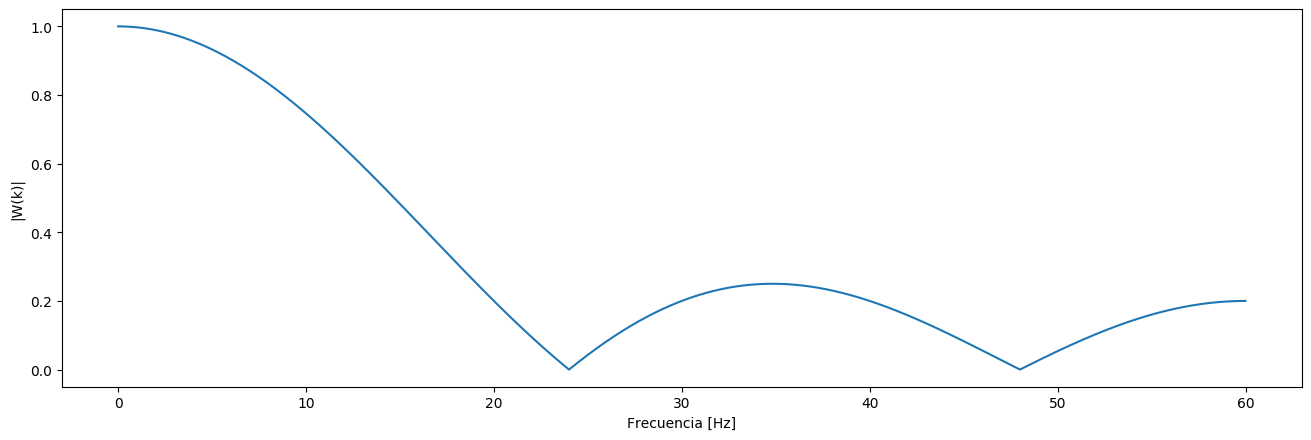

In [13]:
w = np.append(np.ones(5),np.zeros(len(val) - 5))
w = w / (len(w))
w_f = np.fft.rfft(w)/np.max(np.fft.rfft(w))
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:-1],abs(w_f))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|W(k)|')
plt.show()

¿Y si es más larga?

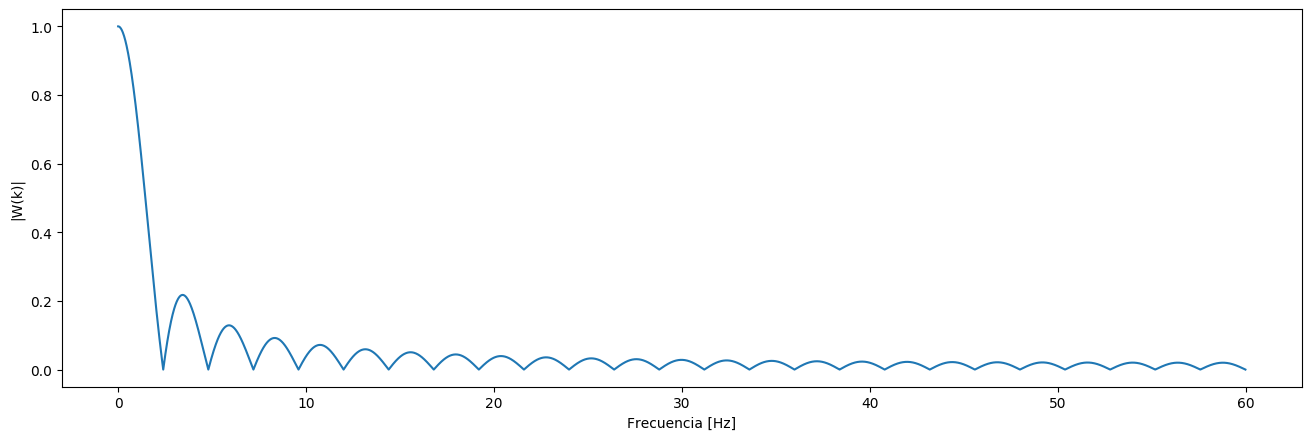

In [14]:
w = np.append(np.ones(50),np.zeros(len(val) - 50))
w = w / (len(w))
w_f = np.fft.rfft(w)/np.max(np.fft.rfft(w))
plt.figure(figsize=(16,5), dpi=100)
plt.plot(f[:-1],abs(w_f))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|W(k)|')
plt.show()

Apliquémosle este último filtro a nuestra señal

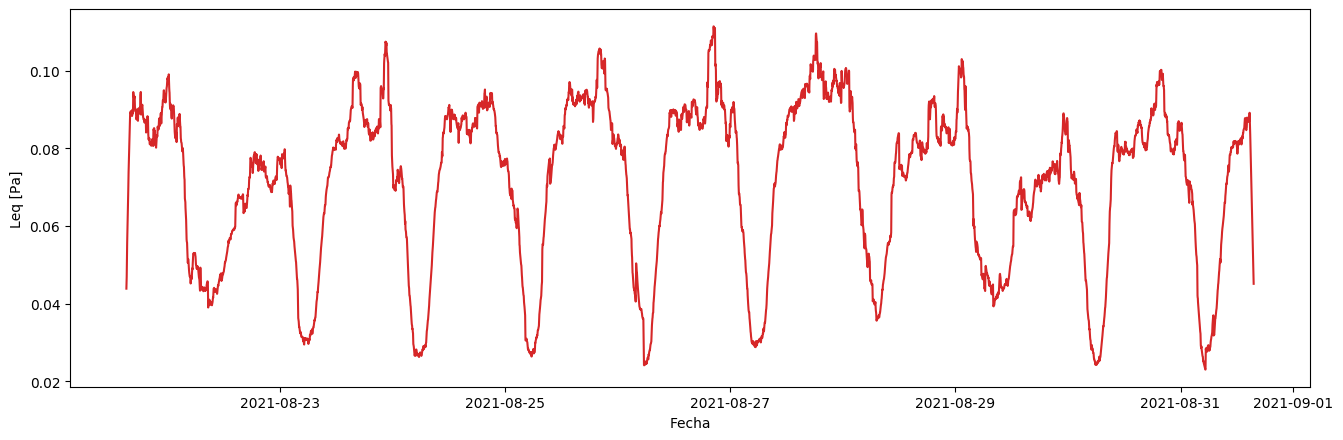

In [15]:
w = (1/50) * np.ones(np.int(50))
val_filt = sig.fftconvolve(val,w,mode='same')
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index,val_filt, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [Pa]')
plt.show()

Ahora, qué pasaría si usáramos una ventana mucho más corta?

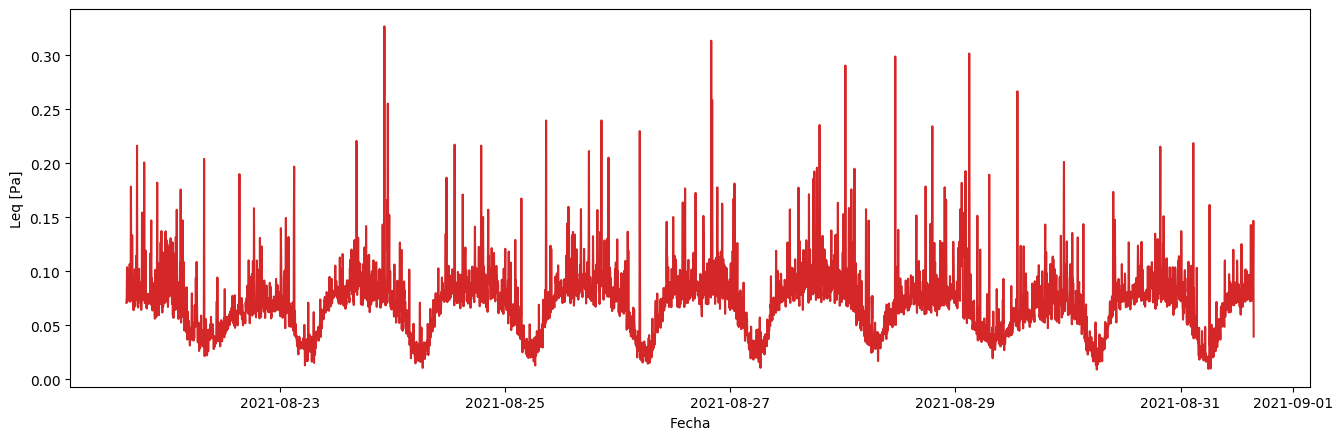

In [16]:
w = (1/2) * np.ones(np.int(2))
val_filt = sig.fftconvolve(val,w,mode='same')
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index,val_filt, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [Pa]')
plt.show()

La frecuencia de corte es tan alta que no se filtra practicamente nada.

Y si la ventana fuera mucho más larga?

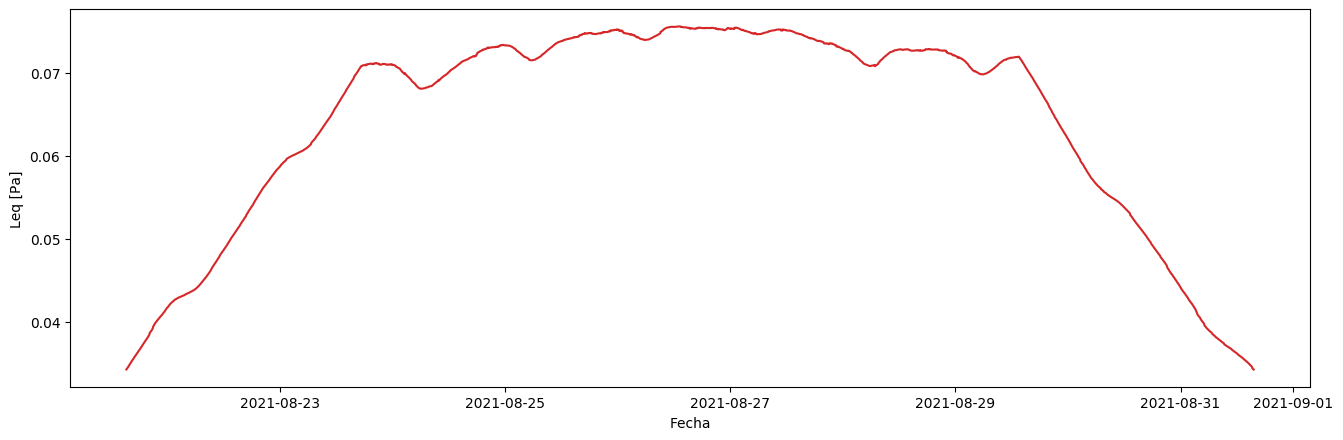

In [17]:
w = (1/3000) * np.ones(np.int(3000))
val_filt = sig.fftconvolve(val,w,mode='same')
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index,val_filt, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [Pa]')
plt.show()

La señal se filtró tanto que ya no tiene nada que ver con la original, a medida que tomamos más muestras para el proceso nos acercamos más al valor promedio de la señal.

Usemos un valor intermedio y pasemos a dBA.

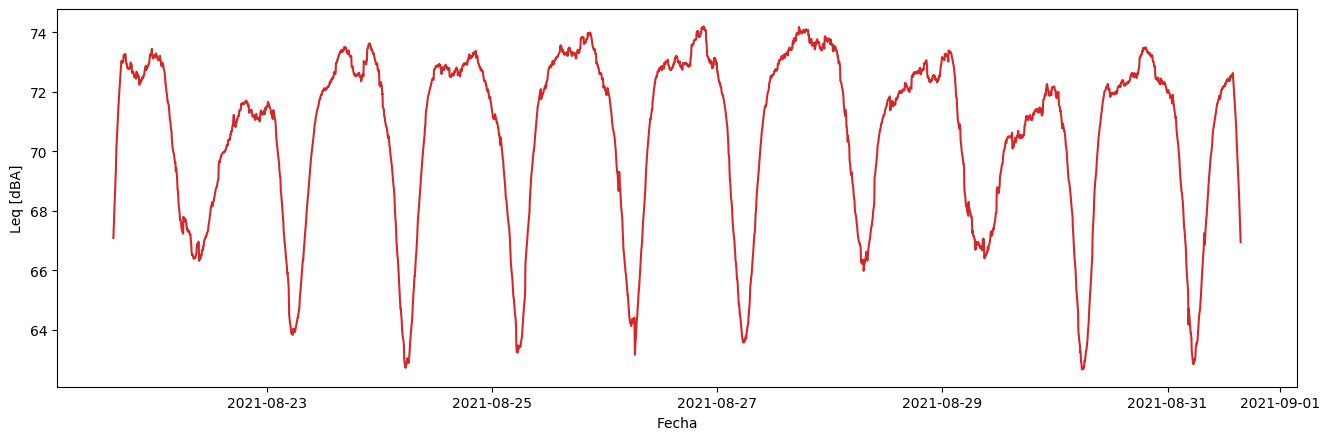

In [18]:
w = (1/100) * np.ones(np.int(100))
val_filt = sig.fftconvolve(val,w,mode='same')
val_filt = 20*np.log10(val_filt/pref)
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index,val_filt, color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [dBA]')
plt.show()

Bastante mejor que la señal original

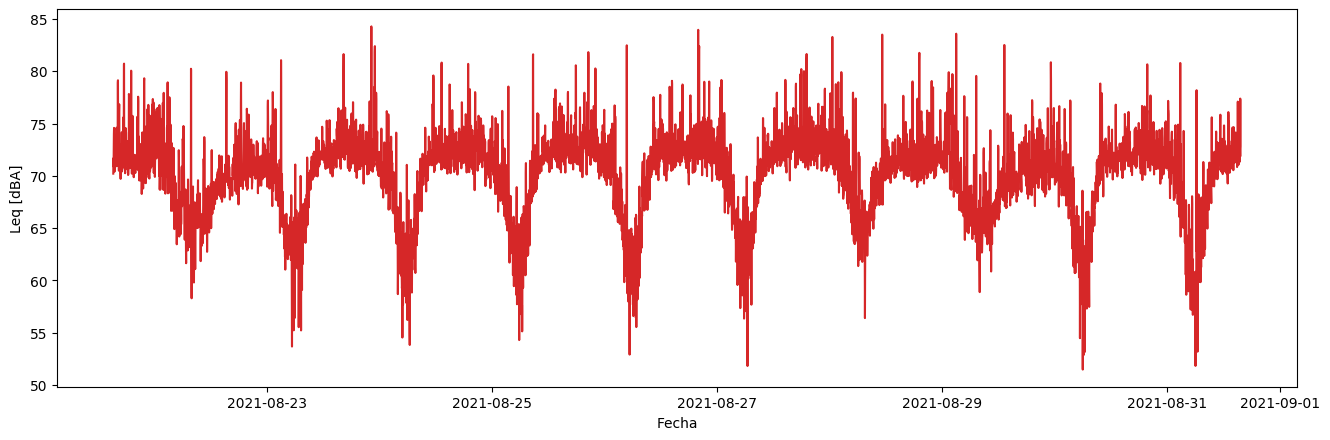

In [19]:
plt.figure(figsize=(16,5), dpi=100)
plt.plot(df.index, 20*np.log10(df.value/pref), color='tab:red')
plt.xlabel('Fecha')
plt.ylabel('Leq [dBA]')
plt.show()

Reescribamos el DataFrame y guardemos la versión nueva para la gente del GIRA.

In [20]:
df.value = np.around(val_filt,2)
df.head()

,id,value,f500,seg,f125,lMin,f1000,f8000,f4000,soundExpLVL,...,memo,timeStamp,f31,f2000,lMax,min,global,cpu,temp,f250
date,,,,,,,,,,,,,,,,,,,,,
2021-08-31 15:35:01+00:00,C06lct7WIdrs1VXhiI5s,66.95,63.88,46,55.83,57.74,66.86,52.97,63.40,74.02,...,19.09,1630424101,44.50,65.95,77.01,34.0,71.94,7.4,60.15,61.78
2021-08-31 15:33:00+00:00,T6MkNQko71mAFliVjpRp,67.11,73.99,46,57.43,62.05,69.70,54.39,66.30,79.32,...,19.08,1630423980,43.29,68.65,90.24,32.0,77.24,7.4,60.15,67.84
2021-08-31 15:31:00+00:00,SW0E8AX8QTJOGadJIIE2,67.32,74.15,46,58.28,59.43,69.88,53.68,66.05,79.46,...,19.10,1630423860,42.26,68.62,90.24,30.0,77.38,7.7,60.15,68.20
2021-08-31 15:29:01+00:00,BvWFZZ0gbC2eHwMb8t1r,67.50,66.10,47,57.46,57.02,65.80,54.87,64.85,74.91,...,19.10,1630423741,45.22,66.97,77.09,28.0,72.83,7.0,60.15,63.62
2021-08-31 15:27:01+00:00,gUS1NnfMPyzTV4qqk8Ey,67.62,64.89,46,56.34,59.05,65.53,55.14,65.39,74.56,...,19.07,1630423621,45.29,67.06,76.83,26.0,72.48,7.8,60.15,62.08


In [21]:
df.to_csv('ruido_urbano_filt.csv')